In [3]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the project directory in Drive
SAVE_DIR = '/content/drive/MyDrive/MLP_Project/'
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)
    print(f"Created directory: {SAVE_DIR}")
else:
    print(f"Using directory: {SAVE_DIR}")

Mounted at /content/drive
Created directory: /content/drive/MyDrive/MLP_Project/


# MLP Project: Heart Failure Prediction

# **Imports**

In [4]:
import torch
from torch import nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader

import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split

# **1. Dataset Preparation**

## Load Dataset

In [5]:
df_train = pd.read_csv('https://raw.githubusercontent.com/imnotnima/MLP/main/dataset/train.csv')

print("Train shape:", df_train.shape)
df_train.head()

Train shape: (249, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
1,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
2,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
3,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
4,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,1


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       249 non-null    float64
 1   anaemia                   249 non-null    int64  
 2   creatinine_phosphokinase  249 non-null    int64  
 3   diabetes                  249 non-null    int64  
 4   ejection_fraction         249 non-null    int64  
 5   high_blood_pressure       249 non-null    int64  
 6   platelets                 249 non-null    float64
 7   serum_creatinine          249 non-null    float64
 8   serum_sodium              249 non-null    int64  
 9   sex                       249 non-null    int64  
 10  smoking                   249 non-null    int64  
 11  time                      249 non-null    int64  
 12  DEATH_EVENT               249 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 25.4 KB


In [7]:
X = df_train.drop("DEATH_EVENT", axis=1)
y = df_train["DEATH_EVENT"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (249, 12)
y shape: (249,)

Target distribution:
DEATH_EVENT
0    171
1     78
Name: count, dtype: int64


## Split (80% train / 20% validation)

In [8]:
x_train, x_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(x_train.shape)
print(x_valid.shape)

(199, 12)
(50, 12)


## Preprocess
### Convert to tensor

In [9]:
# train
x_train = torch.FloatTensor(x_train.values)
y_train = torch.LongTensor(y_train.values)

# validation
x_valid = torch.FloatTensor(x_valid.values)
y_valid = torch.LongTensor(y_valid.values)

print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)

torch.Size([199, 12]) torch.Size([199])
torch.Size([50, 12]) torch.Size([50])


### Standardization

In [10]:
mu = x_train.mean(dim=0)
std = x_train.std(dim=0)

x_train = (x_train - mu) / std
x_valid = (x_valid - mu) / std

print("mu:", mu)
print("std:", std)

mu: tensor([6.0219e+01, 4.2714e-01, 5.4105e+02, 4.2211e-01, 3.8070e+01, 3.5678e-01,
        2.5625e+05, 1.3776e+00, 1.3642e+02, 6.1809e-01, 3.2161e-01, 1.2722e+02])
std: tensor([1.1654e+01, 4.9591e-01, 8.5071e+02, 4.9514e-01, 1.1662e+01, 4.8026e-01,
        9.2773e+04, 1.0038e+00, 4.5396e+00, 4.8708e-01, 4.6827e-01, 7.6376e+01])


## DataLoader
- Initial batch size: **4**

In [11]:
batch_size = 4

train_data = TensorDataset(x_train, y_train)
train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

valid_data = TensorDataset(x_valid, y_valid)
valid_loader = DataLoader(
    valid_data,
    batch_size=batch_size,
    shuffle=False
)

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(valid_loader))

Number of training batches: 50
Number of validation batches: 13


In [12]:
x_batch, y_batch = next(iter(train_loader))
print(x_batch.shape, y_batch.shape)

torch.Size([4, 12]) torch.Size([4])


# **2. Neural Network Model**

In [13]:
num_feats = 12
num_class = 2

h1 = 32
h2 = 16

model = nn.Sequential(
    nn.Linear(num_feats, h1),
    nn.ReLU(),
    nn.Linear(h1, h2),
    nn.ReLU(),
    nn.Linear(h2, num_class)
)

model

Sequential(
  (0): Linear(in_features=12, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=2, bias=True)
)

## Loss & Optimizer (SGD as required)

In [14]:
loss_fn = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01
)

print("Loss:", loss_fn)
print("Optimizer:", optimizer)

Loss: CrossEntropyLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


## Print bias parameters of the final layer **BEFORE** training

In [15]:
# Final layer is model[4] (last Linear)
bias_before = model[4].bias.data.clone()
print("Bias parameters of the final layer BEFORE training:")
print(bias_before)

Bias parameters of the final layer BEFORE training:
tensor([0.0517, 0.2357])


# **3. Device**

In [16]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device being used:", device)
print("Type of device:", type(device))

model = model.to(device)
print("\nModel is on:", next(model.parameters()).device)

Device being used: cuda
Type of device: <class 'str'>

Model is on: cuda:0


# **4. Model Training**

## Utils (AverageMeter + TorchMetrics)

In [17]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [18]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.1 MB/s eta 0:00:00


In [19]:
from torchmetrics import Accuracy

## Train Loooop!

In [20]:
num_epochs = 200

loss_train_hist = []
loss_valid_hist = []
acc_train_hist = []
acc_valid_hist = []

print(f"Starting training for {num_epochs} epochs on {device}...\n")
start_time = time.time()

for epoch in range(num_epochs):

    # ---------- train ----------
    model.train()
    loss_train = AverageMeter()
    acc_train = Accuracy(task="multiclass", num_classes=2).to(device)

    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)
        loss = loss_fn(outputs, targets)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_train.update(loss.item())
        acc_train(outputs, targets)

    # ---------- validation ----------
    model.eval()
    loss_valid = AverageMeter()
    acc_valid = Accuracy(task="multiclass", num_classes=2).to(device)

    with torch.no_grad():
        for inputs, targets in valid_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, targets)

            loss_valid.update(loss.item())
            acc_valid(outputs, targets)

    # history
    loss_train_hist.append(loss_train.avg)
    loss_valid_hist.append(loss_valid.avg)
    acc_train_hist.append(acc_train.compute().item())
    acc_valid_hist.append(acc_valid.compute().item())

    if epoch % 20 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:3d}")
        print(f"  Train: Loss = {loss_train.avg:.4f}, Acc = {acc_train.compute():.4f}")
        print(f"  Valid: Loss = {loss_valid.avg:.4f}, Acc = {acc_valid.compute():.4f}")
        print()

total_time = time.time() - start_time
print(f"Total training time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")

Starting training for 200 epochs on cuda...

Epoch   0
  Train: Loss = 0.6813, Acc = 0.5678
  Valid: Loss = 0.6634, Acc = 0.7400

Epoch  20
  Train: Loss = 0.3582, Acc = 0.8543
  Valid: Loss = 0.3353, Acc = 0.8400

Epoch  40
  Train: Loss = 0.2933, Acc = 0.8693
  Valid: Loss = 0.3092, Acc = 0.9000

Epoch  60
  Train: Loss = 0.2463, Acc = 0.8995
  Valid: Loss = 0.3100, Acc = 0.9000

Epoch  80
  Train: Loss = 0.1973, Acc = 0.9296
  Valid: Loss = 0.3048, Acc = 0.9000

Epoch 100
  Train: Loss = 0.1459, Acc = 0.9497
  Valid: Loss = 0.3503, Acc = 0.8800

Epoch 120
  Train: Loss = 0.0989, Acc = 0.9749
  Valid: Loss = 0.4378, Acc = 0.8400

Epoch 140
  Train: Loss = 0.0626, Acc = 1.0000
  Valid: Loss = 0.4929, Acc = 0.8400

Epoch 160
  Train: Loss = 0.0391, Acc = 1.0000
  Valid: Loss = 0.5978, Acc = 0.8400

Epoch 180
  Train: Loss = 0.0268, Acc = 1.0000
  Valid: Loss = 0.5725, Acc = 0.8400

Epoch 199
  Train: Loss = 0.0200, Acc = 1.0000
  Valid: Loss = 0.6581, Acc = 0.8400

Total training time:

# **5. Results**

## Learning Curves

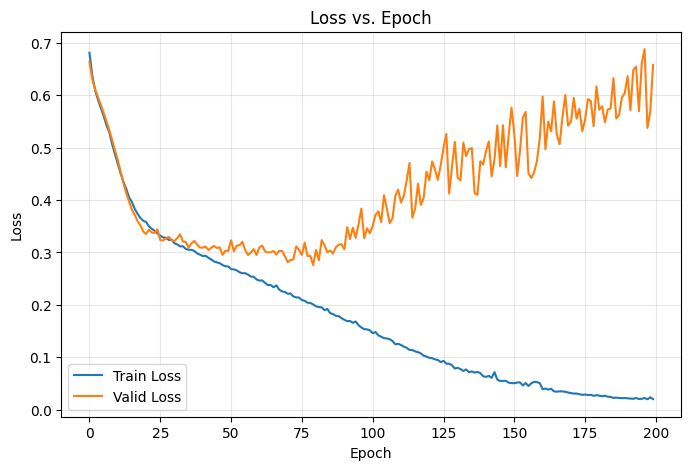

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(range(num_epochs), loss_train_hist, label='Train Loss')
plt.plot(range(num_epochs), loss_valid_hist, label='Valid Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

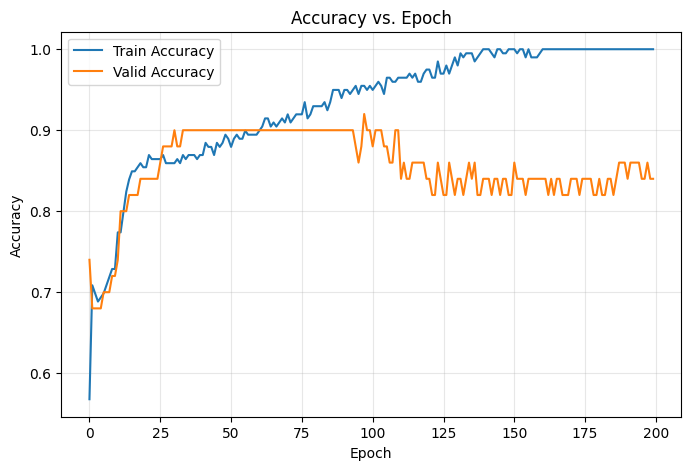

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(range(num_epochs), acc_train_hist, label='Train Accuracy')
plt.plot(range(num_epochs), acc_valid_hist, label='Valid Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Total number of weight and bias parameters

In [23]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of weight and bias parameters: {total_params}")

print("\nParameter breakdown:")
for name, param in model.named_parameters():
    print(f"  {name:20s}  shape={tuple(param.shape)}  numel={param.numel()}")

Total number of weight and bias parameters: 978

Parameter breakdown:
  0.weight              shape=(32, 12)  numel=384
  0.bias                shape=(32,)  numel=32
  2.weight              shape=(16, 32)  numel=512
  2.bias                shape=(16,)  numel=16
  4.weight              shape=(2, 16)  numel=32
  4.bias                shape=(2,)  numel=2


## Final-layer bias AFTER training + comparison

In [24]:
bias_after = model[4].bias.data.clone()
print("Bias parameters of the final layer AFTER training:")
print(bias_after)

print("\nBias parameters of the final layer BEFORE training:")
print(bias_before)

changed = not torch.allclose(bias_before.to(device), bias_after)
print(f"\nDid the bias values change after training? {'Yes' if changed else 'No'}")
if changed:
    print("Difference (after - before):", (bias_after - bias_before.to(device)).detach().cpu())

Bias parameters of the final layer AFTER training:
tensor([ 0.3532, -0.0659], device='cuda:0')

Bias parameters of the final layer BEFORE training:
tensor([0.0517, 0.2357])

Did the bias values change after training? Yes
Difference (after - before): tensor([ 0.3015, -0.3015])


# **6. Save the Model**

In [25]:
# Updated save path to Google Drive
model_save_path = os.path.join(SAVE_DIR, 'heart_failure_mlp.pth')
torch.save(model, model_save_path)
print(f"Model saved to: {model_save_path}")

Model saved to: /content/drive/MyDrive/MLP_Project/heart_failure_mlp.pth


In [26]:
# Reload the model from Google Drive to verify persistence
mymodel = torch.load(model_save_path, weights_only=False)
display(mymodel)

Sequential(
  (0): Linear(in_features=12, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=2, bias=True)
)

# **7. Model Evaluation**

In [27]:
df_test = pd.read_csv('https://raw.githubusercontent.com/imnotnima/MLP/main/dataset/test%20.csv')
print("Test shape:", df_test.shape)
df_test.head()

Test shape: (49, 12)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,75.0,0,582,0,20,1,265000.0,1.9,130,1,0,4
1,90.0,1,47,0,40,1,204000.0,2.1,132,1,1,8
2,62.0,0,231,0,25,1,253000.0,0.9,140,1,1,10
3,87.0,1,149,0,38,0,262000.0,0.9,140,1,0,14
4,80.0,0,148,1,38,0,149000.0,1.9,144,1,1,23


In [28]:
x_test = torch.FloatTensor(df_test.values)
x_test = (x_test - mu) / std   # same standardization as training

print(x_test.shape)

torch.Size([49, 12])


In [29]:
mymodel.eval()

with torch.no_grad():
    x_test = x_test.to(device)
    outputs = mymodel(x_test)
    test_preds = outputs.argmax(dim=1)

print(test_preds)
print("\nPredicted distribution:", torch.bincount(test_preds.cpu()))

tensor([1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0,
        1], device='cuda:0')

Predicted distribution: tensor([26, 23])


## Save predictions (one column named DEATH_EVENT)

In [30]:
predictions_df = pd.DataFrame({
    "DEATH_EVENT": test_preds.cpu().numpy()
})

# Updated predictions path to Google Drive
preds_save_path = os.path.join(SAVE_DIR, 'predictions.csv')
predictions_df.to_csv(preds_save_path, index=False)

print(f"Predictions saved to: {preds_save_path}")
display(predictions_df.head(10))
print(f"\nTotal predictions: {len(predictions_df)}")

Predictions saved to: /content/drive/MyDrive/MLP_Project/predictions.csv


,DEATH_EVENT
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,0
8,1
9,0



Total predictions: 49
